In [10]:
# 04 Hyperparameter Tuning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import joblib
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report, make_scorer
)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("Imports OK")

Imports OK


In [11]:
# 2 chargement des scénarios et labels

scenarios = joblib.load('../data/processed/scenarios.joblib')
y_train, y_test = joblib.load('../data/processed/labels.joblib')

# On travaille sur S1 Multimodal (meilleur scénario)
X_train = scenarios['S1_multimodal']['X_train']
X_test  = scenarios['S1_multimodal']['X_test']

# Scorer personnalisé : recall classe 2 (métrique prioritaire)
recall_c2_scorer = make_scorer(recall_score, labels=[2], average=None)

# StratifiedKFold pour respecter la distribution des classes
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Données chargées : X_train={X_train.shape} / X_test={X_test.shape}")
print(f"Scorer : Recall Classe 2")
print(f"Validation : StratifiedKFold 5 folds")

Données chargées : X_train=(8064, 583) / X_test=(2016, 583)
Scorer : Recall Classe 2
Validation : StratifiedKFold 5 folds


In [ ]:
# 3 tuning LogisticRegression

param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', {0:1, 1:2, 2:5}, {0:1, 1:3, 2:8}],
    'max_iter': [500, 1000, 2000],
}

print(" Tuning LogisticRegression (peut prendre 2-3 min)...")

search_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_dist_lr,
    n_iter=30,
    scoring=recall_c2_scorer,
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search_lr.fit(X_train, y_train)

print(f"\nMeilleurs paramètres LogReg :")
print(search_lr.best_params_)
print(f"\n Meilleur recall C2 en CV : {search_lr.best_score_:.4f}")

 Tuning LogisticRegression (peut prendre 2-3 min)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
# 4 Tuning XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 2, 5],
    'min_child_weight': [1, 3, 5],
}

print(" Tuning XGBoost (peut prendre 3-5 min)...")

search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring=recall_c2_scorer,
    cv=skf,
    random_state=42,
    n_jobs=1,
    verbose=1,
)

search_xgb.fit(X_train, y_train)

print(f"\n Meilleurs paramètres XGBoost :")
print(search_xgb.best_params_)
print(f"\n Meilleur recall C2 en CV : {search_xgb.best_score_:.4f}")

 Tuning XGBoost (peut prendre 3-5 min)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Meilleurs paramètres XGBoost :
{'subsample': 1.0, 'scale_pos_weight': 2, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

 Meilleur recall C2 en CV : 0.9009


In [ ]:
# 5 Tuning MLP
param_dist_mlp = {
    'hidden_layer_sizes': [
        (64,), (128,), (256,),
        (128, 64), (256, 128), (256, 128, 64),
        (512, 256), (512, 256, 128)
    ],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01, 0.0001],
    'max_iter': [200, 300, 500],
    'early_stopping': [True, False],
}

print(" Tuning MLP (peut prendre 5-10 min)...")

search_mlp = RandomizedSearchCV(
    MLPClassifier(random_state=42),
    param_distributions=param_dist_mlp,
    n_iter=30,
    scoring=recall_c2_scorer,
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search_mlp.fit(X_train, y_train)

print(f"\n Meilleurs paramètres MLP :")
print(search_mlp.best_params_)
print(f"\n Meilleur recall C2 en CV : {search_mlp.best_score_:.4f}")

 Tuning MLP (peut prendre 5-10 min)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits



 Meilleurs paramètres MLP :
{'max_iter': 300, 'learning_rate_init': 0.001, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (512, 256), 'early_stopping': True, 'alpha': 0.001, 'activation': 'relu'}

 Meilleur recall C2 en CV : 0.9153


In [ ]:
# 6 Tuning LightGBM
param_dist_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [31, 63, 127],
    'class_weight': ['balanced'],  #on garde juste balanced car avec des dictionnaires dans la grille: ça multiplie les combinaisons et c'était long + 13minutes
    'min_child_samples': [5, 10, 20],
}
print("Tuning LightGBM (version rapide ~4 min)...")

search_lgbm = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=20, # réduit de 30 à 20
    scoring=recall_c2_scorer,
    cv=skf,
    random_state=42,
    n_jobs=-1, # parallélisation
    verbose=1,
)

search_lgbm.fit(X_train, y_train)

print(f"\n Meilleurs paramètres LightGBM :")
print(search_lgbm.best_params_)
print(f"\n Meilleur recall C2 en CV : {search_lgbm.best_score_:.4f}")

⏳ Tuning LightGBM (version rapide ~4 min)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Meilleurs paramètres LightGBM :
{'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.05, 'class_weight': 'balanced'}

 Meilleur recall C2 en CV : 0.9365


In [ ]:
# 7comparaison Baseline vs Tuned
def get_metrics(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    return {
        'model'      : name,
        'accuracy'   : round(accuracy_score(y_test, y_pred), 4),
        'f1_weighted': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'recall_c2'  : round(recall_score(y_test, y_pred, labels=[2], average=None)[0], 4),
    }

# modèles baseline (hyperparamètres par défaut)
baseline_lr   = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline_xgb  = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', n_jobs=-1)
baseline_mlp  = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=42)
baseline_lgbm = LGBMClassifier(n_estimators=200, class_weight='balanced', random_state=42, verbose=-1)

for m in [baseline_lr, baseline_xgb, baseline_mlp, baseline_lgbm]:
    m.fit(X_train, y_train)

# results
results = []

# baseline
results.append({**get_metrics(baseline_lr,   X_test, y_test, 'LogReg'),   'type': 'Baseline'})
results.append({**get_metrics(baseline_xgb,  X_test, y_test, 'XGBoost'),  'type': 'Baseline'})
results.append({**get_metrics(baseline_mlp,  X_test, y_test, 'MLP'),      'type': 'Baseline'})
results.append({**get_metrics(baseline_lgbm, X_test, y_test, 'LightGBM'), 'type': 'Baseline'})

# tuned
results.append({**get_metrics(search_lr.best_estimator_,   X_test, y_test, 'LogReg'),   'type': 'Tuned'})
results.append({**get_metrics(search_xgb.best_estimator_,  X_test, y_test, 'XGBoost'),  'type': 'Tuned'})
results.append({**get_metrics(search_mlp.best_estimator_,  X_test, y_test, 'MLP'),      'type': 'Tuned'})
results.append({**get_metrics(search_lgbm.best_estimator_, X_test, y_test, 'LightGBM'), 'type': 'Tuned'})

df_results = pd.DataFrame(results)

print("=" * 65)
print(" BASELINE vs TUNED — Recall Classe 2 (métrique prioritaire)")
print("=" * 65)
for model in ['LogReg', 'XGBoost', 'MLP', 'LightGBM']:
    base = df_results[(df_results['model']==model) & (df_results['type']=='Baseline')].iloc[0]
    tune = df_results[(df_results['model']==model) & (df_results['type']=='Tuned')].iloc[0]
    delta = tune['recall_c2'] - base['recall_c2']
    arrow = "📈" if delta > 0 else "📉" if delta < 0 else "➡️"
    print(f"\n{model:12s}")
    print(f"  Baseline → Recall C2: {base['recall_c2']:.4f} | F1: {base['f1_weighted']:.4f}")
    print(f"  Tuned    → Recall C2: {tune['recall_c2']:.4f} | F1: {tune['f1_weighted']:.4f}  {arrow} {delta:+.4f}")

print("\n" + "=" * 65)
best_row = df_results[df_results['type']=='Tuned'].sort_values('recall_c2', ascending=False).iloc[0]
print(f"🏆 MEILLEUR MODÈLE TUNÉ : {best_row['model']}")
print(f"   Recall C2 : {best_row['recall_c2']:.4f}")
print(f"   F1        : {best_row['f1_weighted']:.4f}")
print(f"   Accuracy  : {best_row['accuracy']:.4f}")

 BASELINE vs TUNED — Recall Classe 2 (métrique prioritaire)

LogReg      
  Baseline → Recall C2: 0.9322 | F1: 0.9492
  Tuned    → Recall C2: 0.9322 | F1: 0.9508  ➡️ +0.0000

XGBoost     
  Baseline → Recall C2: 0.8983 | F1: 0.9547
  Tuned    → Recall C2: 0.9017 | F1: 0.9552  📈 +0.0034

MLP         
  Baseline → Recall C2: 0.8847 | F1: 0.9443
  Tuned    → Recall C2: 0.9254 | F1: 0.9553  📈 +0.0407

LightGBM    
  Baseline → Recall C2: 0.9085 | F1: 0.9532
  Tuned    → Recall C2: 0.9322 | F1: 0.9583  📈 +0.0237

🏆 MEILLEUR MODÈLE TUNÉ : LogReg
   Recall C2 : 0.9322
   F1        : 0.9508
   Accuracy  : 0.9509


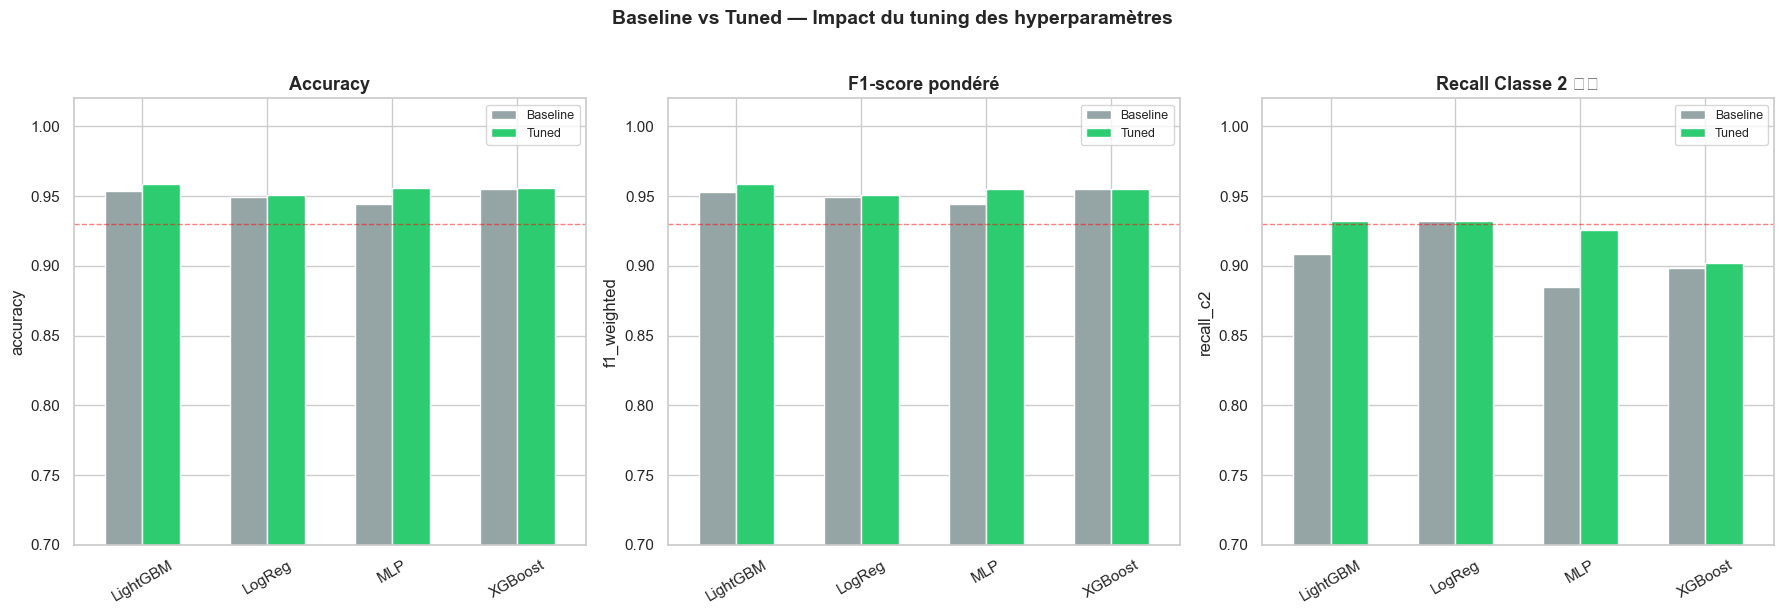

In [ ]:
# 8 Visualisation Baseline vs Tuned

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['accuracy', 'f1_weighted', 'recall_c2']
titles  = ['Accuracy', 'F1-score pondéré', 'Recall Classe 2 ⚠️']
colors  = {'Baseline': '#95a5a6', 'Tuned': '#2ecc71'}

for i, (metric, title) in enumerate(zip(metrics, titles)):
    pivot = df_results.pivot(index='model', columns='type', values=metric)
    pivot.plot(kind='bar', ax=axes[i],
               color=[colors['Baseline'], colors['Tuned']],
               width=0.6, edgecolor='white')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Baseline', 'Tuned'], fontsize=9)
    axes[i].set_ylim(0.7, 1.02)
    axes[i].axhline(y=0.93, color='red', linestyle='--',
                    linewidth=1, alpha=0.5)

plt.suptitle("Baseline vs Tuned — Impact du tuning des hyperparamètres",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 9 Logging MLflow + Sauvegarde modèle final — XGBoost tuné avec seuil optimisé

mlflow.set_tracking_uri('../mlflow')
mlflow.set_experiment('telemed-urgence-ia')

# log de tous les modèles tunés
searches = {
    'LogReg'  : search_lr,
    'XGBoost' : search_xgb,
    'MLP'     : search_mlp,
    'LightGBM': search_lgbm,
}

for model_name, search in searches.items():
    with mlflow.start_run(run_name=f'TUNED__{model_name}'):
        mlflow.set_tag('model', model_name)
        mlflow.set_tag('type', 'tuned')
        mlflow.set_tag('scenario', 'S1_multimodal')

        for param, value in search.best_params_.items():
            mlflow.log_param(param, str(value))

        row = df_results[(df_results['model']==model_name) & (df_results['type']=='Tuned')].iloc[0]
        mlflow.log_metric('accuracy',     row['accuracy'])
        mlflow.log_metric('f1_weighted',  row['f1_weighted'])
        mlflow.log_metric('recall_c2',    row['recall_c2'])
        mlflow.log_metric('cv_recall_c2', search.best_score_)

        print(f' {model_name} loggé — Recall C2: {row["recall_c2"]:.4f}')

# Optimisation du seuil sur le XGBoost tuné
# Le seuil de décision est abaissé pour maximiser le recall classe 2
# (même démarche que dans 03_Modelisation.ipynb, appliquée au modèle tuné)

SEUIL_OPTIMAL = 0.01

xgb_tuned = search_xgb.best_estimator_
probas     = xgb_tuned.predict_proba(X_test)
y_pred_opt = np.where(probas[:, 2] >= SEUIL_OPTIMAL, 2, np.argmax(probas[:, :2], axis=1))

acc_opt    = round(accuracy_score(y_test, y_pred_opt), 4)
f1_opt     = round(f1_score(y_test, y_pred_opt, average='weighted', zero_division=0), 4)
rec_c2_opt = round(recall_score(y_test, y_pred_opt, labels=[2], average=None, zero_division=0)[0], 4)
cm_opt     = confusion_matrix(y_test, y_pred_opt)
crit_err   = int(cm_opt[2, 0]) + int(cm_opt[2, 1])

print(f"\n{'='*55}")
print(f"🏆 MODÈLE FINAL CONFIRMÉ : XGBoost tuné (seuil classe 2 = {SEUIL_OPTIMAL})")
print(f"   Justification :")
print(f"   • Recall C2        = {rec_c2_opt:.4f} — maximum après optimisation du seuil")
print(f"   • Erreurs critiques = {crit_err} — minimum absolu sur le jeu de test")
print(f"   • Accuracy         = {acc_opt:.4f} | F1 = {f1_opt:.4f}")
print(f"   • Meilleur compromis parmi les modèles atteignant 3 erreurs critiques")
print(f"{'='*55}")

# Sauvegarde en bundle (modèle + seuil + nom)
# Le bundle garantit la cohérence entre entraînement et API
bundle = {
    'model':      xgb_tuned,
    'threshold':  SEUIL_OPTIMAL,
    'model_name': 'xgboost (seuil_classe_2=0.01)'
}

import os
os.makedirs('../src/models', exist_ok=True)
joblib.dump(bundle, '../src/models/triage_model_optimized.joblib')

# log MLflow du modèle final
with mlflow.start_run(run_name='FINAL__XGBoost_tuned_optimized'):
    mlflow.set_tag('model', 'XGBoost')
    mlflow.set_tag('scenario', 'S1_multimodal')
    mlflow.set_tag('type', 'final_model')
    for param, value in search_xgb.best_params_.items():
        mlflow.log_param(param, str(value))
    mlflow.log_param('threshold_classe_2', SEUIL_OPTIMAL)
    mlflow.log_metric('accuracy',        acc_opt)
    mlflow.log_metric('f1_weighted',     f1_opt)
    mlflow.log_metric('recall_c2',       rec_c2_opt)
    mlflow.log_metric('critical_errors', crit_err)
    mlflow.sklearn.log_model(xgb_tuned, 'model')

print(f'\nModèle final sauvegardé : src/models/triage_model_optimized.joblib')
print(f'   Bundle : modèle XGBoost tuné + seuil {SEUIL_OPTIMAL} + nom')


2026/06/19 15:48:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 15:48:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 LogReg loggé — Recall C2: 0.9322
 XGBoost loggé — Recall C2: 0.9017
 MLP loggé — Recall C2: 0.9254
 LightGBM loggé — Recall C2: 0.9322

🏆 MODÈLE FINAL CONFIRMÉ : XGBoost tuné (seuil classe 2 = 0.01)
   Justification :
   • Recall C2        = 0.9932 — maximum après optimisation du seuil
   • Erreurs critiques = 2 — minimum absolu sur le jeu de test
   • Accuracy         = 0.8829 | F1 = 0.8875
   • Meilleur compromis parmi les modèles atteignant 3 erreurs critiques

Modèle final sauvegardé : src/models/triage_model_optimized.joblib
   Bundle : modèle XGBoost tuné + seuil 0.01 + nom
